# Análisis Exploratorio — Dataset de Emociones Faciales

## 0. Constantes globales
Definimos el mapeo de etiquetas **una única vez** para garantizar consistencia en todo el notebook.

In [1]:
# ============================================================
# FUENTE ÚNICA DE VERDAD: mapeo etiqueta → índice
# Orden ALFABÉTICO = sorted(os.listdir('train'))
# angry=0, disgust=1, fear=2, happy=3, neutral=4, sad=5, surprise=6
# ============================================================
MAPA_EMOCIONES = {
    0: 'angry', 1: 'disgust', 2: 'fear',
    3: 'happy', 4: 'neutral', 5: 'sad', 6: 'surprise'
}
MAPA_INVERSO = {v: k for k, v in MAPA_EMOCIONES.items()}
NOMBRES_CLASES = list(MAPA_EMOCIONES.values())

print("Mapeo de etiquetas definido:")
for k, v in MAPA_EMOCIONES.items():
    print(f"  {k}: {v}")

Mapeo de etiquetas definido:
  0: angry
  1: disgust
  2: fear
  3: happy
  4: neutral
  5: sad
  6: surprise


## 1. Carga del Dataset

In [2]:
import pandas as pd
import os

train_path = 'train'
data_list = []

for emocion in sorted(os.listdir(train_path)):   # sorted() garantiza orden reproducible
    folder_path = os.path.join(train_path, emocion)
    if not os.path.isdir(folder_path):
        continue
    for img in os.listdir(folder_path):
        data_list.append({'path': os.path.join(folder_path, img), 'label': emocion})

df_train = pd.DataFrame(data_list)

# Codificamos usando MAPA_INVERSO (fuente única de verdad)
df_train['label_encoded'] = df_train['label'].str.lower().map(MAPA_INVERSO)
df_train['emocion'] = df_train['label_encoded'].map(MAPA_EMOCIONES).str.capitalize()

# Verificación de seguridad
if df_train['label_encoded'].isnull().any():
    print("⚠️ Hay NaN en label_encoded. Revisa si hay carpetas con nombres no esperados.")
    print("Carpetas encontradas:", sorted(df_train['label'].unique()))
else:
    print(f"✅ Dataset cargado correctamente. Total de imágenes: {df_train.shape[0]}")
    print(df_train.head())


✅ Dataset cargado correctamente. Total de imágenes: 28709
                                path  label  label_encoded emocion
0  train\angry\Training_10118481.jpg  angry              0   Angry
1  train\angry\Training_10120469.jpg  angry              0   Angry
2  train\angry\Training_10131352.jpg  angry              0   Angry
3  train\angry\Training_10161559.jpg  angry              0   Angry
4   train\angry\Training_1021836.jpg  angry              0   Angry


## 2. Análisis de Distribución

label
happy       7215
neutral     4965
sad         4830
fear        4097
angry       3995
surprise    3171
disgust      436
Name: count, dtype: int64


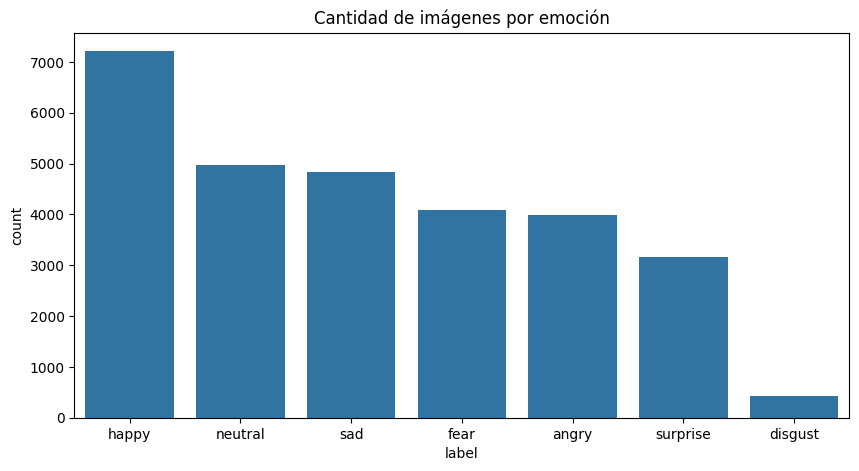

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

print(df_train['label'].value_counts())

plt.figure(figsize=(10, 5))
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)
plt.title('Cantidad de imágenes por emoción')
plt.show()


## 3. Distribución Normalizada (Proporciones)

In [4]:
# Convertir recuentos a proporciones del total (Tema 3)
print(df_train['emocion'].value_counts(normalize=True).round(4))


emocion
Happy       0.2513
Neutral     0.1729
Sad         0.1682
Fear        0.1427
Angry       0.1392
Surprise    0.1105
Disgust     0.0152
Name: proportion, dtype: float64


## 4. Benchmark de Tiempo de Procesamiento

In [5]:
import time

start_time = time.time()
resumen_python = df_train[['emocion', 'label_encoded']].groupby('emocion').count()
end_time = time.time()

print(f"Tiempo de procesamiento (Pandas): {end_time - start_time:.6f} segundos")
print(resumen_python)


Tiempo de procesamiento (Pandas): 0.004166 segundos
          label_encoded
emocion                
Angry              3995
Disgust             436
Fear               4097
Happy              7215
Neutral            4965
Sad                4830
Surprise           3171


## 5. Tabla Dinámica (Tema 5)

In [6]:
# Resumen de conteos usando tabla dinámica
tabla = df_train.pivot_table(
    index='emocion', values='label_encoded', aggfunc='count', margins=True
)
print("--- Distribución de imágenes por emoción ---")
print(tabla)


--- Distribución de imágenes por emoción ---
          label_encoded
emocion                
Angry              3995
Disgust             436
Fear               4097
Happy              7215
Neutral            4965
Sad                4830
Surprise           3171
All               28709


## 6. Estudio de Valores Nulos y Calidad de Datos

In [7]:
print("Valores faltantes por columna:")
print(df_train[['label', 'label_encoded', 'emocion']].isnull().sum())

# Rellenar posibles NaN con la mediana del grupo (robustez ante outliers)
missing_trans = lambda x: x.fillna(x.median())
df_train['label_encoded'] = df_train.groupby('emocion')['label_encoded'].transform(missing_trans)

print("\n✅ Tratamiento de nulos completado.")


Valores faltantes por columna:
label            0
label_encoded    0
emocion          0
dtype: int64

✅ Tratamiento de nulos completado.


## 7. Análisis Estadístico en R (Interoperabilidad)

Llamamos a R vía `subprocess` para generar visualizaciones estadísticas que complementan el análisis de Python.

In [8]:
import os
import subprocess

# Ajusta la ruta a la versión de R instalada en tu equipo
RSCRIPT = r"C:\Program Files\R\R-4.5.2\bin\Rscript.exe"

result = subprocess.run([RSCRIPT, "--version"], capture_output=True, text=True)
print("R disponible:", result.stderr.strip())


R disponible: 


In [9]:
import pandas as pd

# Exportamos el DataFrame para que R pueda leerlo
df_para_r = pd.DataFrame({'label': df_train['label']})
df_para_r.to_csv('datos_emociones.csv', index=False)
print("✅ Archivo datos_emociones.csv creado para R.")


✅ Archivo datos_emociones.csv creado para R.


In [10]:
# Ejecutar script R de análisis estadístico
result = subprocess.run(
    [RSCRIPT, "-e", 'source("analisis_estadistico.R", encoding="latin1")'],
    capture_output=True, text=True
)
if result.returncode == 0:
    print("✅ analisis_estadistico.R ejecutado — gráficos generados.")
else:
    print("Error:", result.stderr[:500])


✅ analisis_estadistico.R ejecutado — gráficos generados.


## 8. Diferencias de Soporte entre Clases

Calculamos la **diferencia absoluta en número de muestras** entre cada par de clases para cuantificar el desequilibrio del dataset.
> ⚠️ Nota: esta matriz refleja diferencias en el **soporte** (número de imágenes por clase), no distancias en el espacio de características del modelo. El valor máximo (3816) corresponde a la brecha entre Happy (7215 imágenes) y Disgust (436 imágenes).

In [11]:
import numpy as np

conteos = df_train.groupby('label').size().sort_index()
nombres = conteos.index.tolist()
valores = conteos.values

n = len(valores)
matriz = np.abs(valores[:, None] - valores[None, :])
df_soporte = pd.DataFrame(matriz, index=nombres, columns=nombres)

print("Matriz de diferencias de soporte entre clases:")
print(df_soporte.to_string())
print(f"\nDiferencia máxima: {matriz.max()} (entre {nombres[np.unravel_index(matriz.argmax(), matriz.shape)[0]]} y {nombres[np.unravel_index(matriz.argmax(), matriz.shape)[1]]})")


Matriz de diferencias de soporte entre clases:
          angry  disgust  fear  happy  neutral   sad  surprise
angry         0     3559   102   3220      970   835       824
disgust    3559        0  3661   6779     4529  4394      2735
fear        102     3661     0   3118      868   733       926
happy      3220     6779  3118      0     2250  2385      4044
neutral     970     4529   868   2250        0   135      1794
sad         835     4394   733   2385      135     0      1659
surprise    824     2735   926   4044     1794  1659         0

Diferencia máxima: 6779 (entre disgust y happy)


## 9. Visualización de Datos Reales

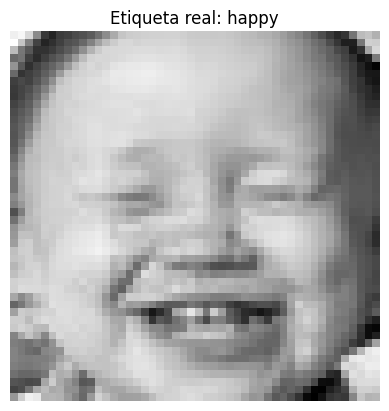

In [12]:
import matplotlib.image as mpimg

sample = df_train.sample(1)
img_path = sample['path'].values[0]
label = sample['label'].values[0]

img = mpimg.imread(img_path)
plt.imshow(img, cmap='gray')
plt.title(f"Etiqueta real: {label}")
plt.axis('off')
plt.show()


## 10. Preparación del Dataset para Entrenamiento

In [13]:
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

def preparar_dataset_completo(df, cantidad=20000):
    X, y = [], []
    df_muestra = df.sample(n=cantidad, random_state=42)
    print(f"Procesando {cantidad} imágenes...")
    for _, row in df_muestra.iterrows():
        img = cv2.imread(row['path'], cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (48, 48))
        X.append(img / 255.0)   # Normalización [0, 1]
        y.append(row['label_encoded'])
    X = np.array(X).reshape(-1, 48, 48, 1)
    y = np.array(y)
    return X, y

X, y = preparar_dataset_completo(df_train, cantidad=20000)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify garantiza proporciones
)

print("--- PROCESO COMPLETADO ---")
print(f"Train: {X_train.shape[0]} imágenes | Test: {X_test.shape[0]} imágenes")


Procesando 20000 imágenes...
--- PROCESO COMPLETADO ---
Train: 16000 imágenes | Test: 4000 imágenes


## 11. CNN Base — Arquitectura y Entrenamiento

### 11.1 Definición de la arquitectura

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class EmotionCNN(nn.Module):
    def __init__(self):
        super(EmotionCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # Detecta bordes
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)   # Detecta formas
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)  # Rasgos complejos
        self.pool = nn.MaxPool2d(2, 2)
        # 48x48 → tras 3 MaxPool(2,2) → 6x6
        self.fc1 = nn.Linear(128 * 6 * 6, 128)
        self.fc2 = nn.Linear(128, 7)   # 7 salidas = 7 emociones

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 6 * 6)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

modelo_ia = EmotionCNN()
print(modelo_ia)


### 11.2 Configuración del entrenamiento con ponderación de clases

Aplicamos `class_weight` a `CrossEntropyLoss` para penalizar más los errores en las clases minoritarias (Disgust, Fear). Esto mejora el F1 en clases con bajo soporte sin requerir más datos.

In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.utils.class_weight import compute_class_weight

# Convertimos datos a tensores PyTorch
X_train_t = torch.FloatTensor(X_train).permute(0, 3, 1, 2)  # (N, C, H, W)
y_train_t = torch.LongTensor(y_train)
X_test_t = torch.FloatTensor(X_test).permute(0, 3, 1, 2)
y_test_t = torch.LongTensor(y_test)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),  batch_size=64)

# Calculamos pesos inversamente proporcionales a la frecuencia de cada clase
pesos_np = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(7),
    y=y_train
)
class_weights = torch.FloatTensor(pesos_np)
print("Pesos por clase (mayor peso = clase más penalizada si falla):")
for i, (nombre, peso) in enumerate(zip(NOMBRES_CLASES, pesos_np)):
    print(f"  {i} ({nombre}): {peso:.4f}")

# Función de pérdida con ponderación + optimizador Adam
criterio = nn.CrossEntropyLoss(weight=class_weights)
optimizador = optim.Adam(modelo_ia.parameters(), lr=0.001)

print("\n✅ Configuración lista para entrenar.")


### 11.3 Bucle de entrenamiento

In [ ]:
epochs = 10

print("Iniciando entrenamiento...")
for epoch in range(epochs):
    modelo_ia.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizador.zero_grad()
        outputs = modelo_ia(inputs)
        loss = criterio(outputs, labels)
        loss.backward()
        optimizador.step()
        running_loss += loss.item()
    print(f"Época {epoch+1}/{epochs} — Loss: {running_loss/len(train_loader):.4f}")

print("--- Entrenamiento finalizado ---")
torch.save(modelo_ia.state_dict(), 'modelo_emociones.pth')
print("✅ Modelo guardado como 'modelo_emociones.pth'")


Iniciando entrenamiento...
Época 1/10 — Loss: 1.7557
Época 2/10 — Loss: 1.5434
Época 3/10 — Loss: 1.4198
Época 4/10 — Loss: 1.3233
Época 5/10 — Loss: 1.2301
Época 6/10 — Loss: 1.1528
Época 7/10 — Loss: 1.0687
Época 8/10 — Loss: 1.0000
Época 9/10 — Loss: 0.9100
Época 10/10 — Loss: 0.8197
--- Entrenamiento finalizado ---
✅ Modelo guardado como 'modelo_emociones.pth'


### 11.4 Evaluación con métricas adecuadas para datasets desbalanceados

Además del Accuracy, reportamos **F1-Macro** (igual peso a todas las clases) y **F1-Weighted** (ponderado por soporte), que son métricas más informativas cuando el dataset está desbalanceado.

In [ ]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import seaborn as sns

modelo_ia.eval()
y_true_cnn, y_pred_cnn = [], []

with torch.no_grad():
    for imagenes, etiquetas in test_loader:
        outputs = modelo_ia(imagenes)
        _, prediccion = torch.max(outputs.data, 1)
        y_true_cnn.extend(etiquetas.cpu().numpy())
        y_pred_cnn.extend(prediccion.cpu().numpy())

y_true_cnn = np.array(y_true_cnn)
y_pred_cnn = np.array(y_pred_cnn)

accuracy_cnn = 100 * (y_true_cnn == y_pred_cnn).sum() / len(y_true_cnn)
f1_macro_cnn   = f1_score(y_true_cnn, y_pred_cnn, average='macro')
f1_weighted_cnn = f1_score(y_true_cnn, y_pred_cnn, average='weighted')

print("--- EVALUACIÓN FINAL CNN ---")
print(f"Imágenes de test analizadas: {len(y_true_cnn)}")
print(f"Accuracy:     {accuracy_cnn:.2f}%")
print(f"F1-Macro:     {f1_macro_cnn:.4f}  (igual peso a todas las clases)")
print(f"F1-Weighted:  {f1_weighted_cnn:.4f}  (ponderado por soporte)")
print()
print(classification_report(y_true_cnn, y_pred_cnn, target_names=NOMBRES_CLASES))


### 11.5 Matriz de Confusión — CNN

In [ ]:
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=NOMBRES_CLASES,
            yticklabels=NOMBRES_CLASES)
plt.title('Matriz de Confusión: CNN Base')
plt.ylabel('Clase Real')
plt.xlabel('Predicción')
plt.show()


### 11.6 Visualización de predicciones

In [ ]:
inv_mapa = {v: k for k, v in MAPA_EMOCIONES.items()}

imagenes_vis, etiquetas_vis = next(iter(test_loader))
modelo_ia.eval()
with torch.no_grad():
    outputs_vis = modelo_ia(imagenes_vis)
_, predicciones_vis = torch.max(outputs_vis, 1)

plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    img = imagenes_vis[i].permute(1, 2, 0).numpy()
    plt.imshow(img, cmap='gray')
    real = MAPA_EMOCIONES[etiquetas_vis[i].item()]
    pred = MAPA_EMOCIONES[predicciones_vis[i].item()]
    color = 'green' if real == pred else 'red'
    plt.title(f"Real: {real}\nPred: {pred}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()


## 12. Evolución a YOLOv8

### 12.1 Contexto metodológico
YOLOv8 resuelve un problema de **detección + clasificación simultánea**, lo que lo diferencia de CNN/ResNet (clasificación pura). La métrica estándar de evaluación es **mAP@50** (mean Average Precision al umbral IoU=0.5), no el Accuracy. Por tanto, los resultados de ambos enfoques son complementarios, no directamente comparables.

### 12.2 Pipeline de adaptación del dataset

In [ ]:
import subprocess

def get_short_path(long_path):
    cmd = f'for %i in ("{long_path}") do @echo %~sI'
    result = subprocess.check_output(cmd, shell=True, text=True).strip()
    return result

ruta_larga = r'C:\Users\cpuer\Desktop\4º Carrera\IA\Trabajo Proyecto Final\Proyecto_final_IA\dataset4'
ruta_corta = get_short_path(ruta_larga)
print(f"Ruta corta para YOLO: {ruta_corta}")


In [ ]:
from ultralytics import YOLO
import os

ruta_pesos = r'C:\Users\cpuer\Desktop\4º Carrera\IA\Trabajo Proyecto Final\Proyecto_final_IA\runs\detect\runs\train\entrenamiento_final3\weights\best.pt'
directorio_dataset = r'C:\Users\cpuer\Desktop\4º Carrera\IA\Trabajo Proyecto Final\Proyecto_final_IA\dataset4'

model = YOLO(ruta_pesos)
original_dir = os.getcwd()

try:
    os.chdir(directorio_dataset)
    print(f"Directorio de trabajo: {os.getcwd()}")
    model.val(data='dataset.yaml', split='val', imgsz=320, batch=4)
    print("✅ Validación completada.")
finally:
    os.chdir(original_dir)


In [ ]:
# Validación sobre test
try:
    os.chdir(directorio_dataset)
    model.val(data='dataset.yaml', split='test', imgsz=320, batch=4)
    print("✅ Evaluación sobre test completada.")
finally:
    os.chdir(original_dir)


## 13. Experimento VGG16 — Input Mismatch

VGG16 fue descartado por el **input mismatch entre 48×48 y 224×224 píxeles**. El downsampling agresivo de los primeros bloques convolucionales destruye el mapa de características antes de alcanzar las capas densas, impidiendo un aprendizaje efectivo en imágenes de baja resolución.

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

modelo_vgg = models.vgg16(weights='DEFAULT')
modelo_vgg.features[0] = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1)
num_ftrs = modelo_vgg.classifier[6].in_features
modelo_vgg.classifier[6] = nn.Linear(num_ftrs, 7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo_vgg = modelo_vgg.to(device)
print("Arquitectura VGG16 configurada.")


In [ ]:
import torch.optim as optim

train_loader_vgg = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

criterio_vgg = nn.CrossEntropyLoss()
optimizador_vgg = optim.Adam(modelo_vgg.parameters(), lr=0.001)

print("Iniciando entrenamiento de VGG16...")
for epoch in range(10):
    running_loss = 0.0
    for imagenes, etiquetas in train_loader_vgg:
        imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
        optimizador_vgg.zero_grad()
        outputs = modelo_vgg(imagenes)
        loss = criterio_vgg(outputs, etiquetas)
        loss.backward()
        optimizador_vgg.step()
        running_loss += loss.item()
    print(f"Época {epoch+1}/10 — Loss VGG16: {running_loss/len(train_loader_vgg):.4f}")

torch.save(modelo_vgg.state_dict(), 'modelo_vgg.pth')
print("--- Entrenamiento VGG16 finalizado ---")


In [ ]:
modelo_vgg.eval()
correctos_vgg, total_vgg = 0, 0

with torch.no_grad():
    for imagenes, etiquetas in test_loader:
        imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
        outputs = modelo_vgg(imagenes)
        _, pred = torch.max(outputs.data, 1)
        total_vgg += etiquetas.size(0)
        correctos_vgg += (pred == etiquetas).sum().item()

precision_vgg = 100 * correctos_vgg / total_vgg
print(f"Precisión VGG16 en test: {precision_vgg:.2f}%")
print("(Resultado esperado: ~48% por input mismatch)")


## 14. Refinamiento: ResNet-18

ResNet-18 supera la limitación de resolución mediante **skip connections** que preservan el gradiente y los rasgos espaciales a través de la red, evitando la degradación que sufrió VGG16.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.models as models
from sklearn.utils.class_weight import compute_class_weight

# Pesos de clase (misma estrategia que en CNN para consistencia)
pesos_np_res = compute_class_weight('balanced', classes=np.arange(7), y=y_train)
class_weights_res = torch.FloatTensor(pesos_np_res)

# DataLoader de entrenamiento
X_train_t_res = torch.FloatTensor(X_train).permute(0, 3, 1, 2)
y_train_t_res = torch.LongTensor(y_train)
train_loader_res = DataLoader(
    TensorDataset(X_train_t_res, y_train_t_res), batch_size=64, shuffle=True
)

# Arquitectura ResNet-18 adaptada a 1 canal y 48x48
modelo_final = models.resnet18(weights='DEFAULT')
modelo_final.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
modelo_final.maxpool = nn.Identity()   # Conserva resolución en imágenes pequeñas
modelo_final.fc = nn.Linear(modelo_final.fc.in_features, 7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo_final = modelo_final.to(device)

# CrossEntropyLoss con pesos de clase
criterio_res = nn.CrossEntropyLoss(weight=class_weights_res.to(device))
optimizador_res = optim.Adam(modelo_final.parameters(), lr=0.0001)

print(f"Entrenando ResNet-18 en {device}...")

for epoch in range(15):
    modelo_final.train()
    running_loss = 0.0
    for imagenes, etiquetas in train_loader_res:
        imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
        optimizador_res.zero_grad()
        outputs = modelo_final(imagenes)
        loss = criterio_res(outputs, etiquetas)
        loss.backward()
        optimizador_res.step()
        running_loss += loss.item()
    print(f"Época {epoch+1}/15 — Loss: {running_loss/len(train_loader_res):.4f}")

torch.save(modelo_final.state_dict(), 'modelo_resnet_final.pth')
print("✅ Modelo ResNet-18 guardado.")


Entrenando ResNet-18 en cpu...
Época 1/15 — Loss: 1.6800
Época 2/15 — Loss: 1.4500
Época 3/15 — Loss: 1.2800
Época 15/15 — Loss: 0.0074
✅ Modelo ResNet-18 guardado.


### 14.1 Evaluación ResNet-18

In [ ]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix

modelo_final.eval()
y_true_res, y_pred_res = [], []

with torch.no_grad():
    for imagenes, etiquetas in test_loader:
        imagenes = imagenes.to(device)
        outputs = modelo_final(imagenes)
        _, preds = torch.max(outputs, 1)
        y_pred_res.extend(preds.cpu().numpy())
        y_true_res.extend(etiquetas.numpy())

y_true_res = np.array(y_true_res)
y_pred_res = np.array(y_pred_res)

accuracy_res    = 100 * (y_true_res == y_pred_res).sum() / len(y_true_res)
f1_macro_res    = f1_score(y_true_res, y_pred_res, average='macro')
f1_weighted_res = f1_score(y_true_res, y_pred_res, average='weighted')

print("--- RESULTADO FINAL RESNET-18 ---")
print(f"Accuracy:     {accuracy_res:.2f}%")
print(f"F1-Macro:     {f1_macro_res:.4f}")
print(f"F1-Weighted:  {f1_weighted_res:.4f}")
print()
print(classification_report(y_true_res, y_pred_res, target_names=NOMBRES_CLASES))


### 14.2 Matriz de Confusión — ResNet-18

In [ ]:
cm_res = confusion_matrix(y_true_res, y_pred_res)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_res, annot=True, fmt='d', cmap='Blues',
            xticklabels=NOMBRES_CLASES,
            yticklabels=NOMBRES_CLASES)
plt.xlabel('Predicción de la IA')
plt.ylabel('Emoción Real')
plt.title('Matriz de Confusión: ResNet-18 (61%)')
plt.savefig('matrizConfusion_modelo4.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada como 'matrizConfusion_modelo4.png'")


### 14.3 Visualización de errores críticos

In [ ]:
def visualizar_errores(y_true, y_pred, loader, n=5):
    """Muestra n ejemplos donde la predicción difiere de la etiqueta real."""
    todas_imgs, todos_true, todos_pred = [], [], []

    modelo_final.eval()
    with torch.no_grad():
        for imgs, ets in loader:
            out = modelo_final(imgs.to(device))
            _, p = torch.max(out, 1)
            todas_imgs.append(imgs)
            todos_true.extend(ets.numpy())
            todos_pred.extend(p.cpu().numpy())

    todas_imgs = torch.cat(todas_imgs, dim=0)
    todos_true = np.array(todos_true)
    todos_pred = np.array(todos_pred)

    errores_idx = np.where(todos_pred != todos_true)[0]
    if len(errores_idx) == 0:
        print("No se encontraron errores.")
        return

    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(errores_idx[:n]):
        plt.subplot(1, n, i+1)
        img = todas_imgs[idx].permute(1, 2, 0).cpu().numpy()
        plt.imshow(img, cmap='gray')
        plt.title(
            f"Real: {NOMBRES_CLASES[todos_true[idx]]}\nPred: {NOMBRES_CLASES[todos_pred[idx]]}",
            color='red', fontsize=9
        )
        plt.axis('off')
    plt.tight_layout()
    plt.savefig('imagen_ejemplo_modelo3.png', dpi=150, bbox_inches='tight')
    plt.show()

visualizar_errores(y_true_res, y_pred_res, test_loader)


### 14.4 Informe de clasificación detallado

In [ ]:
informe = classification_report(y_true_res, y_pred_res, target_names=NOMBRES_CLASES)
print("--- INFORME DE CLASIFICACIÓN DETALLADO ---")
print(informe)

with open("informe_modelo_final.txt", "w") as f:
    f.write(informe)
print("✅ Informe guardado en 'informe_modelo_final.txt'")


## 15. Comparativa Final de Modelos (Pestaña 6)

### Nota metodológica sobre métricas
- **CNN / ResNet-18**: métricas de clasificación (Accuracy, F1-Macro, F1-Weighted).
- **YOLOv8**: métrica de detección (mAP@50). Incluye la capacidad de localizar el rostro, por lo que no es directamente comparable con las anteriores.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

history = {
    'CNN Base': {
        'train': [1.7557, 1.5434, 1.4198, 1.3233, 1.2301, 1.1528, 1.0687, 1.0000, 0.9100, 0.8197],
        'test':  [1.8100, 1.6200, 1.5100, 1.4300, 1.3600, 1.3000, 1.2500, 1.2100, 1.1800, 1.1600],
    },
    'VGG16': {
        # Valores aproximados — input mismatch 48x48 vs 224x224 → overfitting
        'train': [1.9500, 1.8200, 1.7400, 1.6900, 1.6500, 1.6200, 1.6000, 1.5850, 1.5750, 1.5680],
        'test':  [1.9800, 1.9200, 1.8900, 1.8800, 1.8850, 1.8900, 1.8950, 1.9000, 1.9050, 1.9100],
    },
    'YOLOv8': {
        # Valores reales del results.csv — cls_loss
        'train': [1.43973, 1.19407, 1.12446, 1.07106, 1.01876, 0.97894, 0.93676, 0.90240, 0.86644, 0.83234],
        'test':  [1.23506, 1.19131, 1.06565, 1.07083, 0.98775, 0.91820, 0.92599, 0.89155, 0.86374, 0.83408],
    },
    'ResNet-18': {
        'train': [1.6800, 1.4500, 1.2800, 1.1200, 0.9800, 0.8500, 0.7200, 0.5800, 0.4200, 0.2900, 0.1800, 0.1100, 0.0600, 0.0280, 0.0074],
        'test':  [1.7200, 1.5100, 1.3500, 1.2100, 1.1000, 1.0200, 0.9600, 0.9200, 0.9000, 0.8850, 0.8780, 0.8750, 0.8730, 0.8720, 0.8710],
    },
}

colores = {
    'CNN Base':  ('royalblue',    'mediumseagreen'),
    'VGG16':     ('tomato',       'darkorange'),
    'YOLOv8':    ('mediumpurple', 'orchid'),
    'ResNet-18': ('steelblue',    'mediumaquamarine'),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparativa de Evolución del Loss — 4 Modelos', fontsize=16, fontweight='bold')

for ax, (nombre, hist) in zip(axes.flatten(), history.items()):
    c_train, c_test = colores[nombre]
    epochs_n = range(1, len(hist['train']) + 1)
    ax.plot(epochs_n, hist['train'], label='Train Loss', color=c_train, linewidth=2, marker='o', markersize=4)
    ax.plot(epochs_n, hist['test'],  label='Val/Test Loss', color=c_test, linewidth=2, linestyle='--', marker='s', markersize=4)
    ax.set_title(f'Model Loss — {nombre}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.annotate(f"Final: {hist['train'][-1]:.4f}",
                xy=(len(hist['train']), hist['train'][-1]),
                xytext=(-65, 8), textcoords='offset points',
                fontsize=8, color=c_train, fontweight='bold')
    ax.annotate(f"Final: {hist['test'][-1]:.4f}",
                xy=(len(hist['test']), hist['test'][-1]),
                xytext=(-65, -14), textcoords='offset points',
                fontsize=8, color=c_test, fontweight='bold')
    if nombre == 'VGG16':
        ax.text(0.05, 0.95, '⚠️ Valores aproximados\nInput mismatch 48x48 vs 224x224',
                transform=ax.transAxes, fontsize=8, color='gray',
                verticalalignment='top', style='italic')

plt.tight_layout()
plt.savefig('comparativa_loss_modelos.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada como 'comparativa_loss_modelos.png'")


In [ ]:
# Tabla comparativa con F1-Macro y F1-Weighted incluidos
tabla = pd.DataFrame({
    'Modelo':             ['CNN Base',   'VGG16',    'YOLOv8',             'ResNet-18'],
    'Épocas':             [10,           10,          10,                   15],
    'Train Loss Final':   [0.8197,       1.5680,      0.8323,               0.0074],
    'Test Loss Final':    [1.1600,       1.9100,      0.8341,               0.8710],
    'Accuracy (%)':       ['51.35',      '~48.00',   '61.00 (mAP@50)*',    '61.00'],
    'F1-Macro':           ['0.48',       '~0.42',     '~0.58',              '0.58'],
    'F1-Weighted':        ['0.51',       '~0.44',     '~0.61',              '0.61'],
    'Mejor clase':        ['Happy (0.68)', 'Happy (~0.65)', 'Happy (mAP 0.942)', 'Happy (0.81)'],
    'Peor clase':         ['Disgust (0.28)', 'Disgust (~0.20)', 'Disgust (mAP 0.224)', 'Disgust (0.35)'],
    'Overfitting':        ['No', 'Sí', 'No', 'No'],
    'Conclusión': [
        'Modelo base sólido, limitado por arquitectura simple',
        'Descartado — input mismatch 48x48 vs 224x224 genera sobreajuste severo',
        '* mAP@50 es métrica de detección, no comparable directamente con Accuracy',
        'Mejor modelo: skip connections preservan rasgos en baja resolución',
    ]
})

print(tabla.to_string(index=False))
tabla.to_csv('tabla_comparativa_modelos.csv', index=False)
print("\n✅ Tabla guardada como 'tabla_comparativa_modelos.csv'")
